In [2]:
from matplotlib import rc
import numpy as np
import xrft
import matplotlib.pyplot as plt
import os
import xarray as xr
import subprocess
import matplotlib.pyplot as plt

import matplotlib
import shutil
os.chdir("/home/149/ab8992/topographic-NIWs")
import matplotlib
font = {'family' : 'serif',
        'weight':'normal',
        'size'   : 18}
matplotlib.rc('font', **font)
import autolib as al
from dask.distributed import Client
# client = Client()
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 13
Total threads: 104,Total memory: 416.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45379,Workers: 13
Dashboard: /proxy/8787/status,Total threads: 104
Started: Just now,Total memory: 416.00 GiB
Comm: tcp://127.0.0.1:41775,Total threads: 8
Dashboard: /proxy/44267/status,Memory: 32.00 GiB
Nanny: tcp://127.0.0.1:39207,


## Meridional Stopmotion

In [ ]:
v = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/common_common/archive/output*/u.nc",decode_times = False,decode_cf = False).sel(xq = slice(-200,200)).sel(yh = 0,method = "nearest")
e = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/common_common/archive/output*/e.nc",decode_times = False,decode_cf = False).sel(xh = slice(-200,200)).sel(yh = 0,method = "nearest").load()

u = u.interp(xq = e.xh).load()

/jobfs/127439352.gadi-pbs/ipykernel_4171355/3875198367.py:22: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  data_u = data.v.interp(yq = data_e.yh).drop("yq")
/jobfs/127439352.gadi-pbs/ipykernel_4171355/3875198367.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i//2,i%2].set_yticklabels([4000,3000,2000,1000,0])


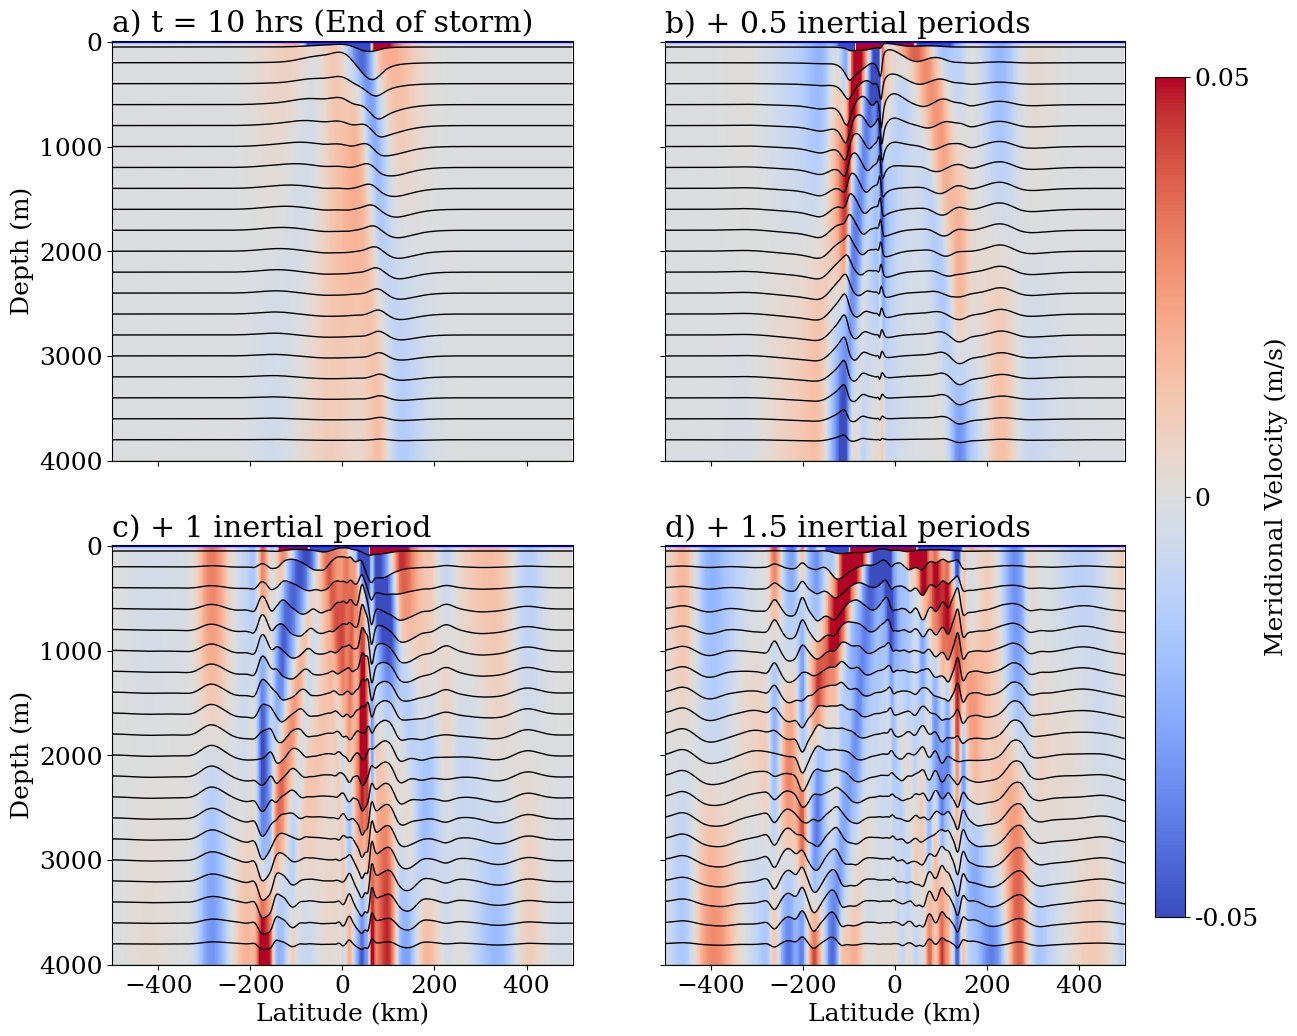

In [76]:
from matplotlib.gridspec import GridSpec
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib
font = {'family' : 'serif',
        'weight':'normal',
        'size'   : 18}
matplotlib.rc('font', **font)
cmap = "coolwarm"
framedim = "time"
import seaborn as sns


# data = xr.merge([
#     xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/common_common/archive/output*/v.nc",decode_times = False,decode_cf = False).sel(xh = 50,method = "nearest").load(),
#     xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/common_common/archive/output*/e.nc",decode_times = False,decode_cf = False).sel(xh = 50,method = "nearest").load()
# ])

# data = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/common_common/archive/output*/*.nc",decode_times = False,decode_cf = False)

data_e = data.e
data_u = data.v.interp(yq = data_e.yh).drop("yq")

# data_u = (data_u - data_u.mean("xh")).sel(yh = slice(-200,200))
data_e = data_e.sel(yh = slice(-500,500))
data_u = data_u.sel(yh = slice(-500,500))
vmax = 0.05
vmin = -1 * vmax

def snapshot(time,ax,):
    tt = time

    scaling = 2 # Scale the anomaly in interface height
    x = data_u.yh
    mean_depths = data_e.isel(time = 0)
    base = mean_depths.isel(zi = 0)
    deviation = (data_e.isel(time = tt).isel(zi = 0) - mean_depths[0,:])
    layer = base + deviation * scaling
    layer.plot(ax = ax,color = "blue",linewidth = 2)
  

    for i in range(0,20):
        prev_layer = layer
        if i == 1:
            scaling = 10
        if i == 3:
            scaling = 15

        base = mean_depths.isel(zi = i+1)
        deviation = (data_e.isel(time = tt).isel(zi = i+1) - mean_depths.isel(zi = i+1))
        layer = base + deviation * scaling
        layer.plot(ax = ax,color = "black",linewidth = 1)


        # Create patch for the clipping of velocity field to fill space between layers. See https://matplotlib.org/stable/tutorials/advanced/path_tutorial.html
        
        # verts = np.vstack([np.stack([x, prev_layer], 1), np.stack([np.flip(x), np.flip(layer * 0 + 4000)], 1)]) ## creates vertices 
        verts = np.vstack([np.stack([x, prev_layer], 1), np.stack([np.flip(x), np.flip(layer)], 1)]) ## creates vertices 
        path = Path(verts)
        patch = PathPatch(path, lw = 2,transform=ax.transData) ## patch to clip the velocity field

        # Plot velocity field and apply patch as clip path
        velfield = data_u.isel(time = tt,zl = i).expand_dims({"vert":2},axis = 1)
        X,Y = np.meshgrid(np.linspace(x[0].values.reshape(1)[0],x[-1].values.reshape(1)[0],x.shape[0]),np.linspace(prev_layer.max().values.reshape(1)[0],layer.min().values.reshape(1)[0],2))
        im = ax.pcolormesh(X, Y, velfield.T,cmap = cmap,vmin = vmin,vmax = vmax)
        im.set_clip_path(patch)

    
    
    ## Handle bottom layer case
    prev_layer = layer
    layer = data_e.isel(time = 0,zi = -1)
    
    layer.plot(ax = ax,color = "green",linewidth = 1)
    
    verts = np.vstack([np.stack([x, layer], 1), np.stack([np.flip(x), np.flip(prev_layer)], 1)])
    path = Path(verts)
    
    patch = PathPatch(path, lw = 2,transform=ax.transData)
    
    # Plot bottom layer velocity
    velfield = data_u.isel(time = tt,zl = -1).expand_dims({"vert":2},axis = 1) 
    X,Y = np.meshgrid(np.linspace(x[0].values.reshape(1)[0],x[-1].values.reshape(1)[0],data_u.yh.shape[0]),np.linspace(prev_layer.max().values.reshape(1)[0],layer.min().values.reshape(1)[0],2))
    im = ax.pcolormesh(X, Y, velfield.T,cmap = cmap,vmin = vmin,vmax = vmax)
    im.set_clip_path(patch)
    ax = plt.gca()
    ax.set_ylim([-4000,10])


    
    return ax
    

fig,axes = plt.subplots(2,2,figsize = (15,12),sharey = True,sharex=True)


start = 10 # hours. Next convert to timesteps/ 3 per hour
start *= 3

## Get inertial period
fp = (2 * np.pi / 0.0001) / 3600
fp_10mins = fp * 3

captions = ["a) t = 10 hrs (End of storm)","b) + 0.5 inertial periods","c) + 1 inertial period","d) + 1.5 inertial periods"]

# for i,time in enumerate([30,60,120,180]):
for i,time in enumerate([start,start + round(fp_10mins * 0.5),start + round(fp_10mins * 1),start + round(fp_10mins * 1.5)]):
    # print(i,time)
    snapshot(time,axes[i//2,i%2])
    axes[i//2,i%2].set_title("")

    axes[i//2,i%2].set_title(captions[i],loc = "left")


    axes[i//2,i%2].set_xlabel("Latitude (km)")
    axes[i//2,i%2].set_ylabel("Depth (m)")
    axes[i//2,i%2].set_yticklabels([4000,3000,2000,1000,0])
    axes[i//2,i%2].set_yticks([-4000,-3000,-2000,-1000,0])
    if i%2 != 0:
        axes[i//2,i%2].set_ylabel("")
    if i//2 != 1:
        axes[i//2,i%2].set_xlabel("")

    # break

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.82, 0.15, 0.02, 0.7])
ticks = [-0.05,0,0.05]

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap="coolwarm"),cax = cbar_ax,label = f"Meridional Velocity (m/s)")
cbar.set_ticks(ticks)
cbar.set_ticklabels(ticks)




## Zonal Stopmotion

In [2]:
u = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/common_common/archive/output*/u.nc",decode_times = False,decode_cf = False).sel(yh = [50,150,200],method = "nearest")
e = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/common_common/archive/output*/e.nc",decode_times = False,decode_cf = False).sel(yh = [50,150,200],method = "nearest").load()

u = u.interp(xq = e.xh).load()

In [3]:
def snapshot_zonal(data_u,data_e,time,ax):
    tt = time

    scaling = 60 # Scale the anomaly in interface height
    x = data_u.xh
    mean_depths = data_e.isel(time = 0)
    base = mean_depths.isel(zi = 0)
    deviation = (data_e.isel(time = tt).isel(zi = 0) - mean_depths[0,:])
    layer = base + deviation * scaling
    layer.plot(ax = ax,color = "blue",linewidth = 2)
  

    for i in range(0,21):
        prev_layer = layer

        if i == 10:
            scaling = 40
        if i == 13:
            scaling = 20
        if i == 15:
            scaling = 10
        ## Plot this layer 
        base = mean_depths.isel(zi = i+1)
        deviation = (data_e.isel(time = tt).isel(zi = i+1) - mean_depths.isel(zi = i+1))
        layer = base + deviation * scaling
        layer.plot(ax = ax,color = "black",linewidth = 1)


        # Create patch for the clipping of velocity field to fill space between layers. See https://matplotlib.org/stable/tutorials/advanced/path_tutorial.html
        
        # verts = np.vstack([np.stack([x, prev_layer], 1), np.stack([np.flip(x), np.flip(layer * 0 + 4000)], 1)]) ## creates vertices 
        verts = np.vstack([np.stack([x, prev_layer], 1), np.stack([np.flip(x), np.flip(layer)], 1)]) ## creates vertices 
        path = Path(verts)
        patch = PathPatch(path, lw = 2,transform=ax.transData) ## patch to clip the velocity field

        # Plot velocity field and apply patch as clip path
        velfield = data_u.isel(time = tt,zl = i).expand_dims({"vert":2},axis = 1)
        X,Y = np.meshgrid(np.linspace(x[0].values.reshape(1)[0],x[-1].values.reshape(1)[0],x.shape[0]),np.linspace(prev_layer.max().values.reshape(1)[0],layer.min().values.reshape(1)[0],2))
        im = ax.pcolormesh(X, Y, velfield.T,cmap = cmap,vmin = vmin,vmax = vmax)
        im.set_clip_path(patch)

    
    
    ## Handle bottom layer case
    prev_layer = layer
    layer = data_e.isel(time = 0,zi = -1)
    
    layer.plot(ax = ax,color = "green",linewidth = 1)
    
    verts = np.vstack([np.stack([x, layer], 1), np.stack([np.flip(x), np.flip(prev_layer)], 1)])
    path = Path(verts)
    
    patch = PathPatch(path, lw = 2,transform=ax.transData)
    
    # Plot bottom layer velocity
    velfield = data_u.isel(time = tt,zl = -1).expand_dims({"vert":2},axis = 1) 
    X,Y = np.meshgrid(np.linspace(x[0].values.reshape(1)[0],x[-1].values.reshape(1)[0],data_u.xh.shape[0]),np.linspace(prev_layer.max().values.reshape(1)[0],layer.min().values.reshape(1)[0],2))
    im = ax.pcolormesh(X, Y, velfield.T,cmap = cmap,vmin = vmin,vmax = vmax)
    im.set_clip_path(patch)
    ax = plt.gca()
    ax.set_ylim([-4000,10])


    
    return ax
from matplotlib.gridspec import GridSpec
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib
font = {'family' : 'serif',
        'weight':'normal',
        'size'   : 18}
matplotlib.rc('font', **font)
cmap = "coolwarm"
framedim = "time"
import seaborn as sns
data = xr.merge([u,e])
data_e = data.e
data_u = data.u
data_u = (data_u - data_u.mean("xh")).sel(xh = slice(-200,200))
data_e = data_e.sel(xh = slice(-200,200))   
vmax = data_u.max().values * 0.1
vmax = 0.01
vmin = -1 * vmax

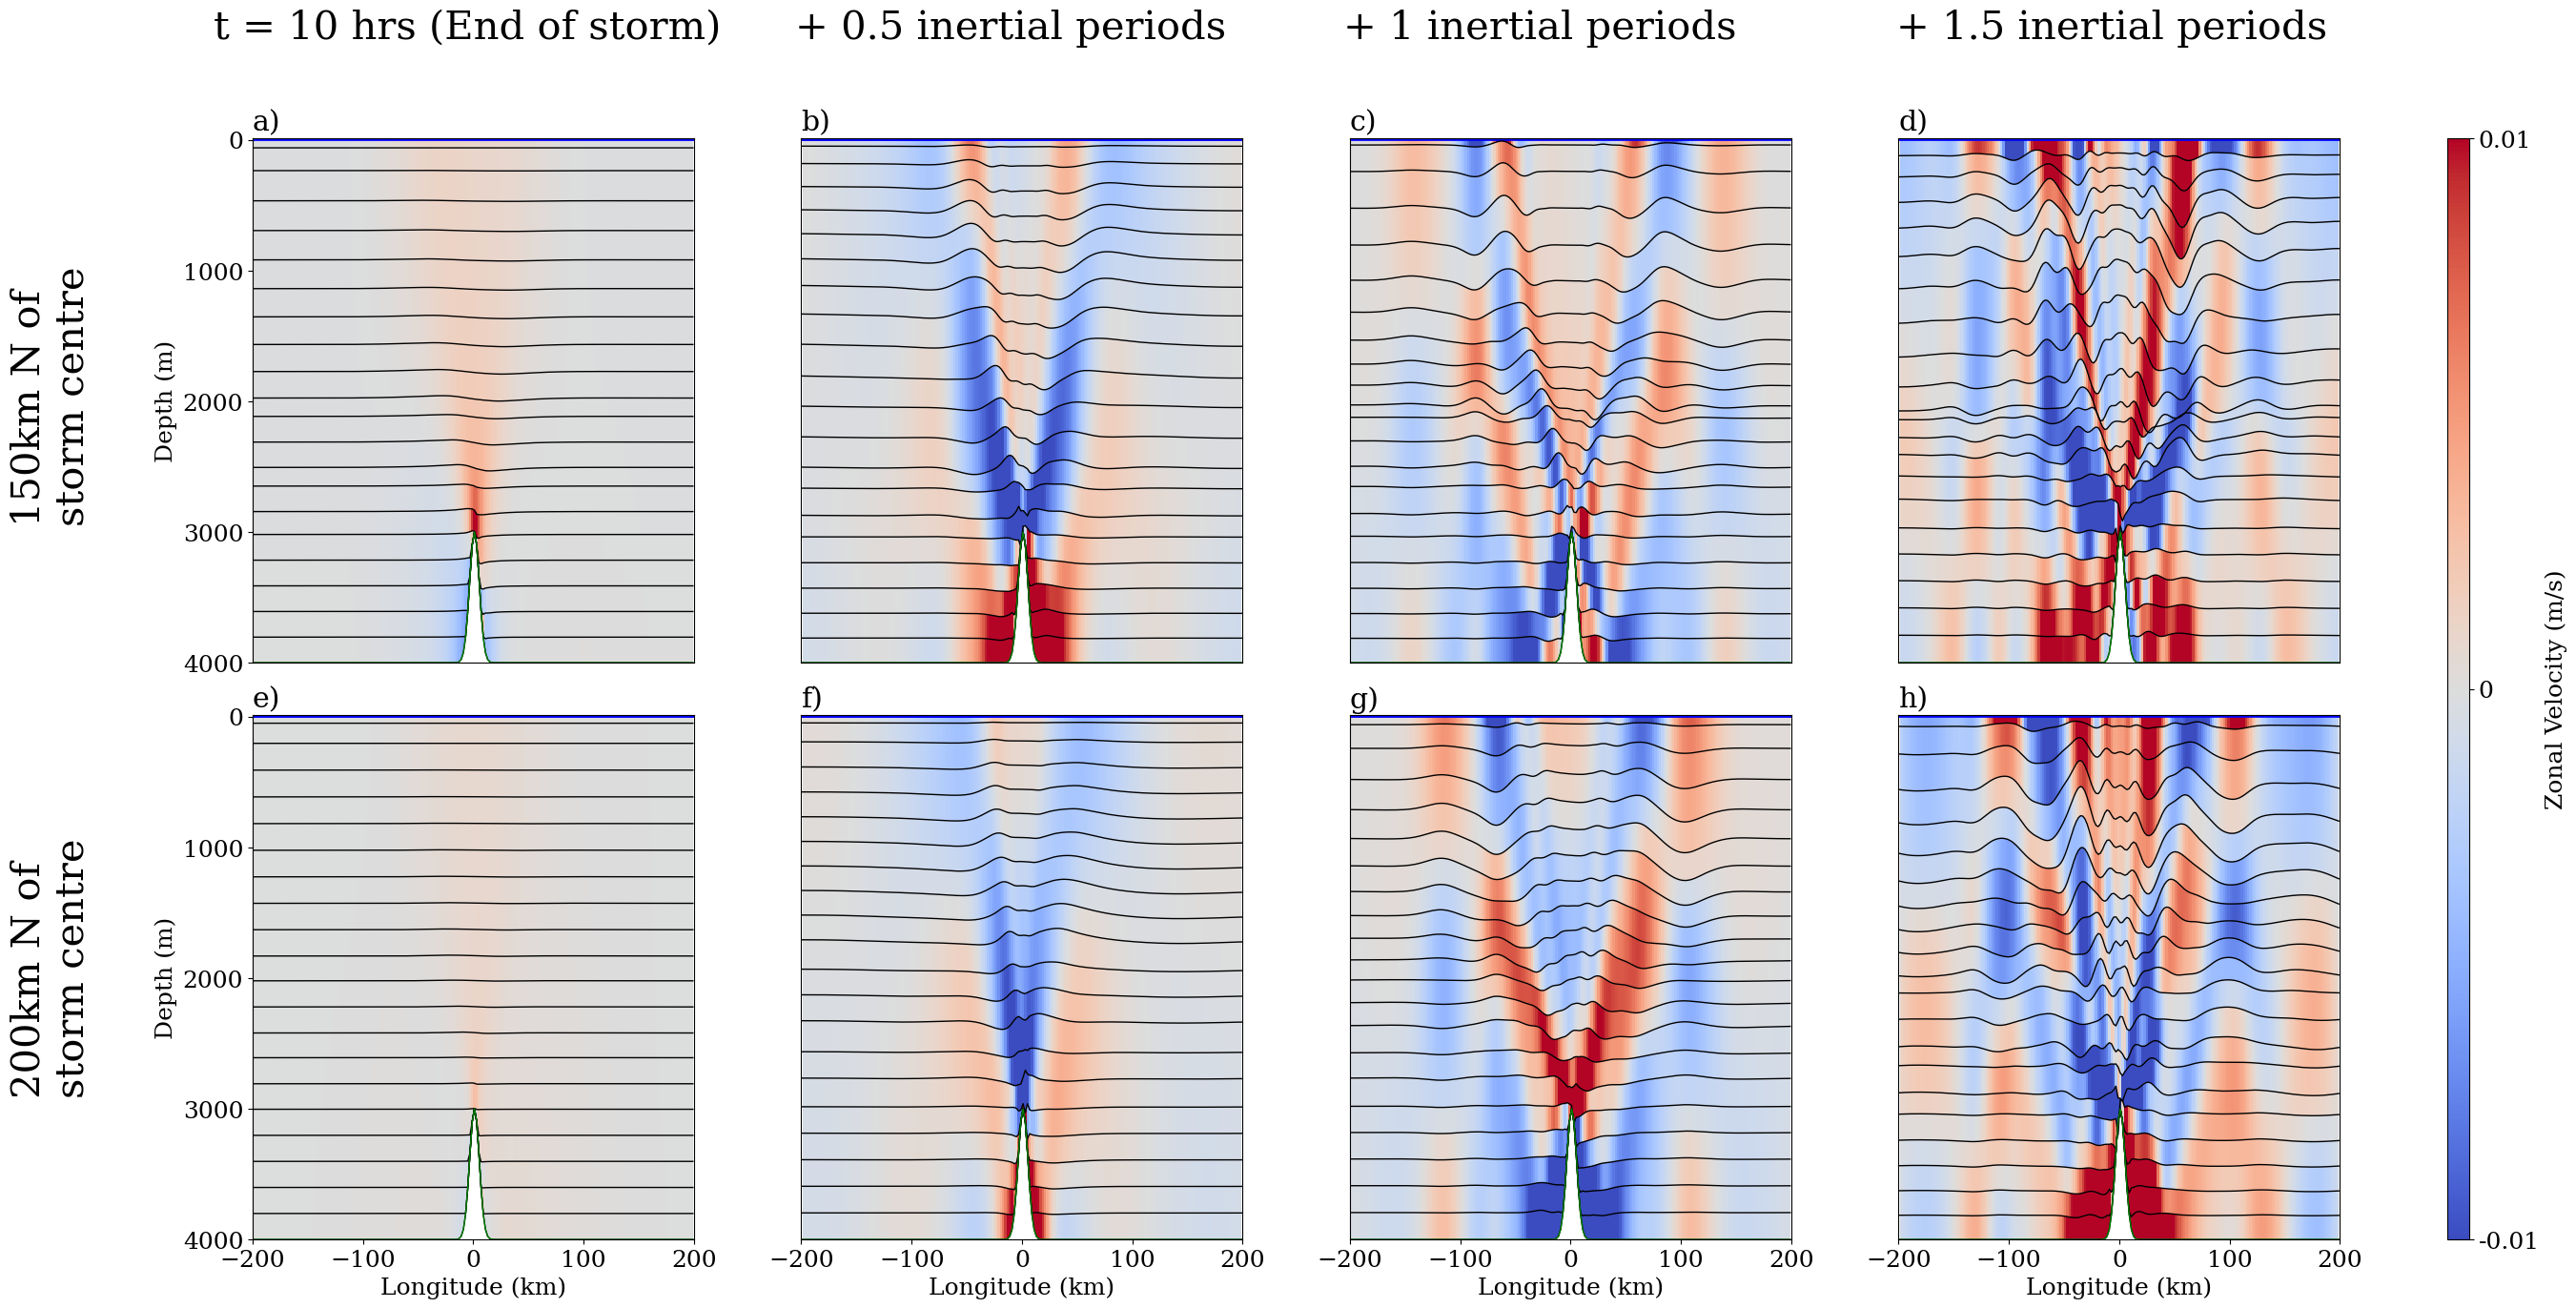

In [111]:
# %matplotlib qt
fig = plt.figure(figsize=(30, 15))
gs = fig.add_gridspec(2, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.1)

axes = []
for j in range(2):
    row_axes = []
    for i in range(4):
        ax = fig.add_subplot(gs[j, i])
        row_axes.append(ax)
    axes.append(row_axes)

start = 10  # hours. Next convert to timesteps/ 3 per hour
start *= 3

## Get inertial period
fp = (2 * np.pi / 0.0001) / 3600
fp_10mins = fp * 3

captions = ["a)", "b)", "c)", "d)", "e)", "f)", "g)", "h)"]

for j, yh in enumerate([150, 200]):
    for i, time in enumerate([start, start + round(fp_10mins * 0.5), start + round(fp_10mins * 1), start + round(fp_10mins * 1.5)]):
        snapshot_zonal(data_u.sel(yh=yh, method="nearest"), data_e.sel(yh=yh, method="nearest"), time, axes[j][i])
        axes[j][i].set_title("")
        axes[j][i].set_title(captions[i + j * 4], loc="left")
        axes[j][i].set_ylabel("")
        axes[j][i].set_yticks([])
        axes[j][i].set_xlabel("")
        axes[j][i].set_xticks([])

        if i == 0:
            axes[j][i].set_ylabel("Depth (m)")
            axes[j][i].set_yticks([-4000, -3000, -2000, -1000, 0])
            axes[j][i].set_yticklabels([4000, 3000, 2000, 1000, 0])

        if j == 1:
            axes[j][i].set_xlabel("Longitude (km)")

            axes[j][i].set_xticks([-200, -100, 0,100, 200])
        axes[j][i].set_ylim([-4000, 10])

# Add row labels
fig.text(0.04, 0.7, '150km N of \nstorm centre', va='center', rotation='vertical', fontsize=30)
fig.text(0.04, 0.3, '200km N of \nstorm centre', va='center', rotation='vertical', fontsize=30)
fig.text(0.2, 0.95, 't = 10 hrs (End of storm)', ha='center', fontsize=30)
fig.text(0.39, 0.95, '+ 0.5 inertial periods', ha='center', fontsize=30)
fig.text(0.575, 0.95, '+ 1 inertial periods', ha='center', fontsize=30)
fig.text(0.775, 0.95, '+ 1.5 inertial periods', ha='center', fontsize=30)
# Add colorbar
cbar_ax = fig.add_subplot(gs[:, -1])
scale_vel = 1
norm = matplotlib.colors.Normalize(vmin=scale_vel * vmin, vmax=scale_vel * vmax)
cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap="coolwarm"), cax=cbar_ax, label="Zonal Velocity (m/s)")
cbar.set_ticks([scale_vel * vmin, 0, scale_vel * vmax])
cbar.set_ticklabels([round(scale_vel * vmin, 4), 0, round(scale_vel * vmax, 4)])

plt.show()


## Spectrum

/jobfs/127576159.gadi-pbs/ipykernel_2556859/3292246975.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  d = np.log(xrft.power_spectrum(us.isel(zl = 5,yh = 1).drop("xq"),dim = ["xh","time"]))


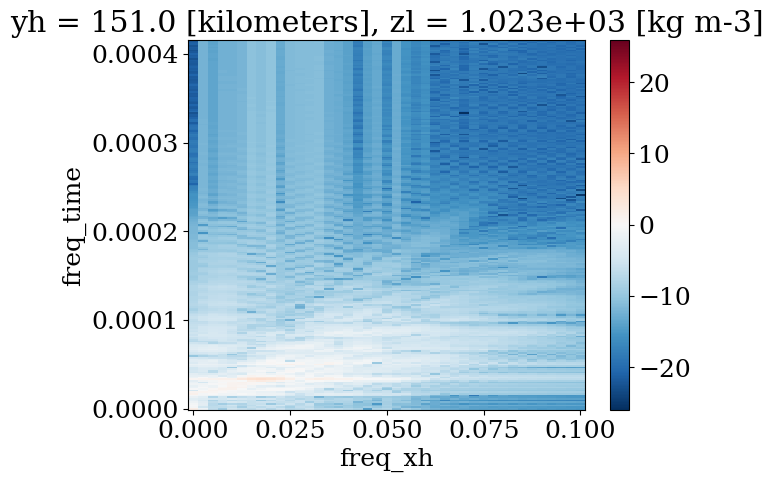

In [6]:
## Spectrum
import xrft
us = (data.u - data.u.mean("xh")).sel(xh = slice(-200,200))
d = np.log(xrft.power_spectrum(us.isel(zl = 5,yh = 1).drop("xq"),dim = ["xh","time"]))
d.sel(freq_time = slice(0,None),freq_xh = slice(0,0.1)).plot()


## Perturbation expts

In [ ]:
## Collect the data from september runs
expts = ["duration","strength","height","width"]
width_correction = np.sqrt(np.log(2)) #! Correction factor to change widths to FWHM
from pathlib import Path
basepath = Path("/g/data/v45/ab8992/postprocessed_bottomniws")
data = {}
for expt in ["duration","forcing_width","height","strength","width"]:
    # expt = expt.name
    data[expt] = xr.Dataset(
    coords={"pert": []},
    data_vars={
        "EF_NS": (["pert"], []),
        "EF_EW": (["pert"], [])
    }
    )
    for run in (basepath / expt).glob("*"):
        run = run.name
        ds = xr.open_mfdataset(str(basepath / expt / run / f"{run}*.nc"), decode_cf=False, decode_times=False)
        data[expt] = xr.concat([data[expt], xr.Dataset(
            coords={"pert": [float(run.split("_")[-1])]},
            data_vars={
            "EF_NS": (["pert"], [ds.EF_NS*1000 / width_correction]),
            "EF_EW": (["pert"], [ds.EF_EW*1000 / width_correction])
            }
        )], dim="pert")
    if expt == "forcing_width":      #! This fixes the error in get_efs 
       data[expt]["EF_NS"] /= 1000   #! whereby widths were in kms
    if expt == "width":
        data[expt]["EF_EW"] /= 1000
    data[expt] = data[expt].sortby("pert")

common = xr.open_mfdataset(str(basepath / "strength" / "strength_10" / f"*.nc"), decode_cf=False, decode_times=False)
common["EF_EW"] /= width_correction
common["EF_NS"] /= width_correction
data["forcing_width"] = data["forcing_width"].isel(pert = slice(3,None))

data["strength"] = data["strength"].drop_sel(pert = 10)
data["duration"] = data["duration"].drop_sel(pert = 5)
data["duration"] = data["duration"].assign_coords(pert=data["duration"].pert * 2)
data["strength"] = data["strength"].assign_coords(pert = np.sqrt(data["strength"].pert / 2.5e-3))


## Multiply by T / T_tau to correct energy fluxes
T = 10 * 10 * 3600 # 10 lots of 10 hours in seconds
dduration = 10 * 3600
common["EF_NS"] *= 1000 * T / dduration
common["EF_EW"] *= 1000 * T / dduration
for expt in expts:

    if expt != "duration":
        data[expt]["EF_NS"] *= T / dduration
        data[expt]["EF_EW"] *= T / dduration
    else:
        Tx = 9 * 10 * 3600
        duration = data[expt].pert * 3600
        data[expt]["EF_NS"] *= ((Tx + duration) / duration)  
        data[expt]["EF_EW"] *= ((Tx + duration) / duration)  

## Fix up the widths so that X axis plots the FWHM 
data["width"] = data["width"].assign_coords(pert = (data["width"].pert * width_correction))

## Likewise for forcing width
data["forcing_width"]["EF_EW"] *= (data["forcing_width"].pert / 12500)
data["forcing_width"] = data["forcing_width"].assign_coords(pert = (data["forcing_width"].pert * width_correction))

## Fix error with EW energy flux in forcing width
# data["forcing_width"] = data["forcing_width"].assign_coords(pert = (data["forcing_width"].pert * np.sqrt(np.log(2))))

[ 50.  75. 150. 175. 200. 225. 250. 275. 300. 350. 400. 450. 500.]


Text(0.0, 1.0, 'd)')

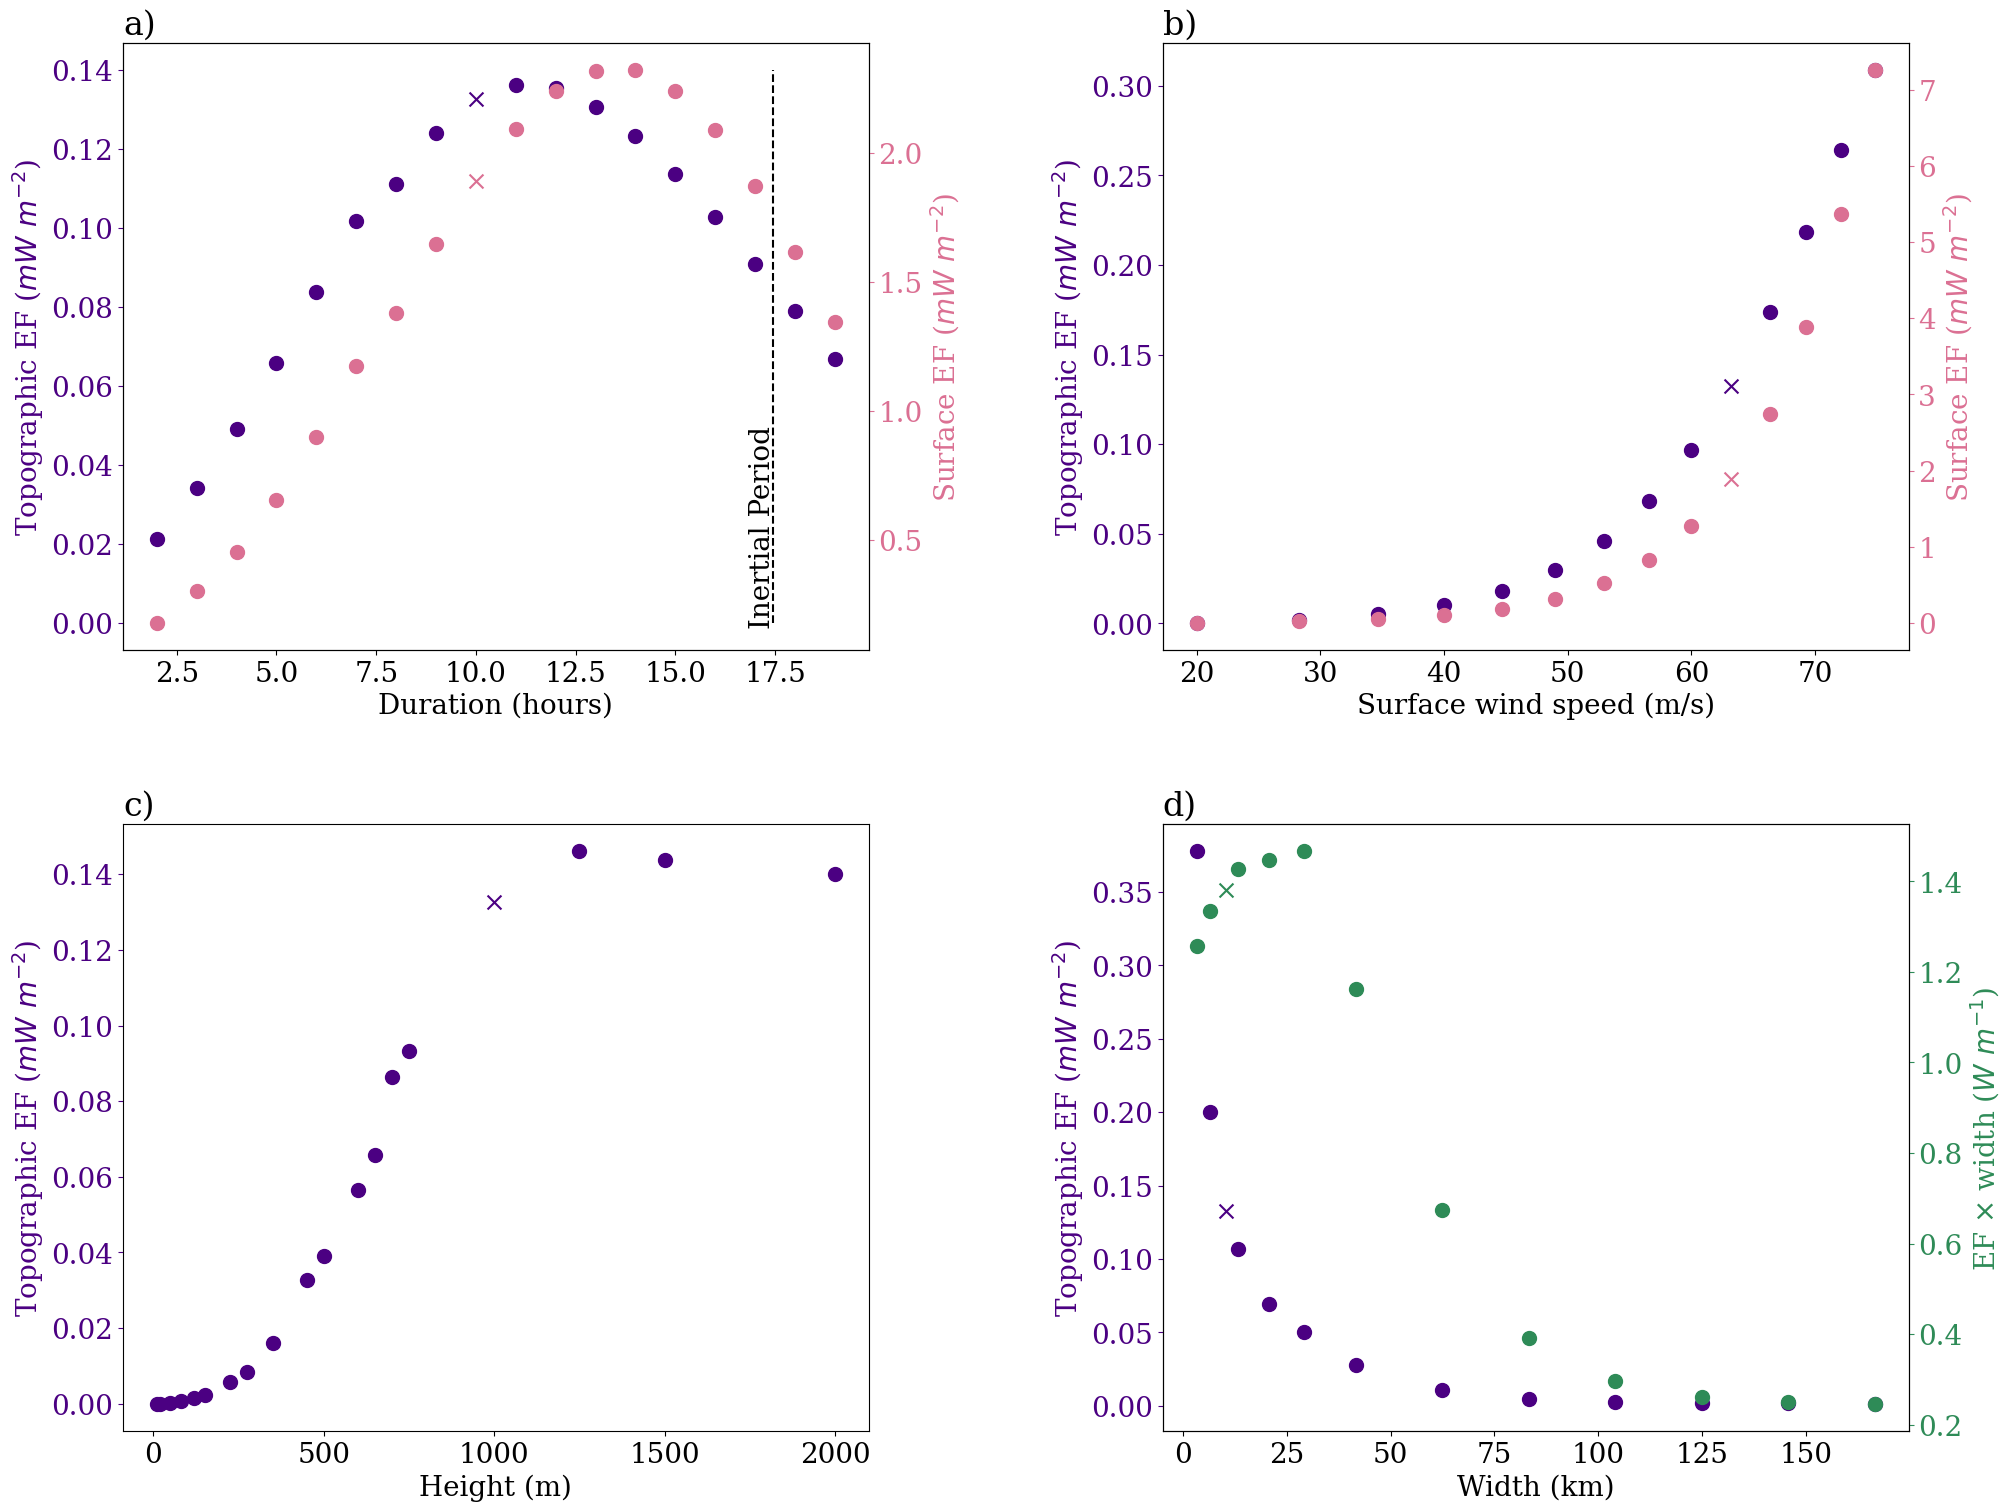

In [61]:

expts = ["duration","strength","height","width"]
font = {'family' : 'serif',
        'weight':'normal',
        'size'   : 20}
matplotlib.rc('font', **font)
fig = plt.figure(figsize=(20, 15),constrained_layout=True)
gs = fig.add_gridspec(3, 3,width_ratios=[1,0.1,1],height_ratios=[1,0.1,1])

ax = [
        fig.add_subplot(gs[0,0]),
        fig.add_subplot(gs[0,2]),
        fig.add_subplot(gs[2,0]),
        fig.add_subplot(gs[2,2])
]

color2= "palevioletred"
color1= "indigo"
color3= "seagreen"

xlabels = {
    "duration":"Duration (hours)",
    "height":"Height (m)",
    "width":"Width (km)",
    "strength":"Surface wind speed (m/s)",
    "forcing_width":"Forcing Width (km)"
}

default_vals = {
    "duration":10,
    "height":1000,
    "strength":np.sqrt(10 / 2.5e-3), #! Convert from Pa to m/s
    "forcing_width":100* width_correction, #! Change width to FWHM
    "width":(12.5) * width_correction} #! Change width to FWHM
markersize = 100
for i,expt in enumerate(expts):

    data[expt].EF_EW.plot.scatter(color = color1,ax = ax[i],s = markersize)
    if expt not in ["height","width"]:
        ax2 = ax[i].twinx()
        data[expt].EF_NS.plot.scatter(color = color2,ax = ax2,s = markersize)
        ax2.scatter(default_vals[expt],common.EF_NS,color = color2,marker = "x",s = markersize)
        ax2.set_ylabel(r"Surface EF ($mW ~m^{-2}$)",color = color2)
        ax2.tick_params(axis='y', colors=color2)
    if expt == "width":
        ax2 = ax[i].twinx()
        (data[expt].EF_EW * data[expt].pert).plot.scatter(color = color3,ax = ax2,s = markersize)
        ax2.scatter(default_vals["width"],common.EF_EW * 12.5 * width_correction,color = color3,marker = "x",s = markersize)

        ax2.set_ylabel(r"EF $\times$ width ($W ~m^{-1}$)",color = color3)
        ax2.tick_params(axis='y', colors=color3)
        # ax2.scatter(xax,yax2,color = color2)
    ax[i].scatter(default_vals[expt],common.EF_EW,color = color1,marker = "x",s = markersize)
    ax[i].set_ylabel(r"Topographic EF ($mW ~m^{-2}$)",color = color1)
    ax[i].set_xlabel(expt)
    ax[i].set_xlabel(xlabels[expt])
    ax[i].tick_params(axis='y', colors=color1)

fp = (2 * np.pi / 0.0001) 
fp_hours = fp / 3600
ax[0].vlines(fp_hours,0,0.14,color = "black",linestyles="--")
## Add text to ax[0] to label the vlines
ax[0].text(fp_hours - 0.6,0.0001,"Inertial Period",rotation = 90)

ax[0].set_title("a)",loc = "left")
ax[1].set_title("b)",loc = "left")
ax[2].set_title("c)",loc = "left")
ax[3].set_title("d)",loc = "left")


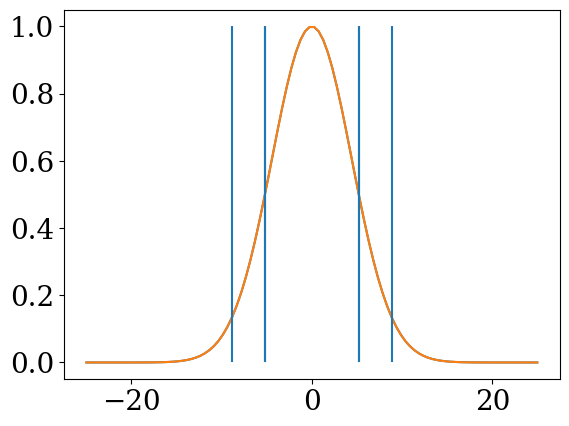

In [47]:
import numpy as np
import matplotlib.pyplot as plt
# Gaussian that we used:
width = 12.5
true_std = width / (2 * np.sqrt(2))
mod_width = width / (2)
x = np.linspace(-width * 2,width * 2,100)
out1 = np.exp(- ( 
                               (2 * (x)) /  width
                               )**2
)
out2 = np.exp(- 
                                 ((x**2)) /  (2 * true_std**2)
    )           
fwhm = 2 * np.sqrt(2 * np.log(2)) * true_std
plt.plot(x,out1)
plt.plot(x,out2)
plt.vlines(fwhm/2,0,1)
plt.vlines(-fwhm/2,0,1)
plt.vlines(true_std*2,0,1)
plt.vlines(-true_std*2,0,1)

width_converter = np.sqrt(np.log(2))
plt.vlines(width * width_converter/2,0,1)
plt.vlines(-width * width_converter/2,0,1)

## We want the ~25 km width to be the 2 std, to quote in text

Text(0.5, 1.0, '')

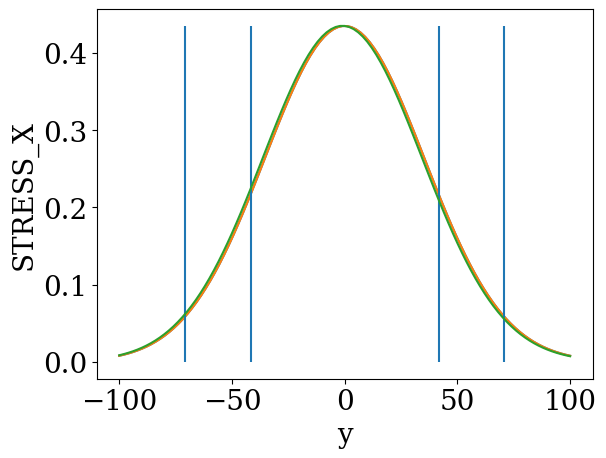

In [123]:
stress = xr.open_dataset("/home/149/ab8992/topographic-NIWs/inputdir/common/storm_windstress.nc").STRESS_X.isel(x = 10,Time = 10).sel(y = slice(-100,100)).load()
width = 100
true_std = width / (2 * np.sqrt(2))
mod_width = width / (2)
pextent = 100
x = np.linspace(-pextent,pextent,100)
out1 = np.exp(- ( 
                               (2 * (x)) /  width
                               )**2
)
out2 = np.exp(- 
                                 ((x**2)) /  (2 * true_std**2)
    )           
fwhm = 2 * np.sqrt(2 * np.log(2)) * true_std
a = np.max(stress.values)

plt.plot(x,out1 * a)
plt.plot(x,out2 * a)
plt.vlines(fwhm/2,0,a)
plt.vlines(-fwhm/2,0,a)
plt.vlines(true_std*2,0,a)
plt.vlines(-true_std*2,0,a)
# topo.depth.plot()
# topo = (4000 - topo).sel(x = slice(-40,40))
stress.plot()
plt.title("")
# topo.vlines

In [3]:
ocean_area = 361e12 # m^2
lee_tw = 0.85e12 #TW
1000 * lee_tw / (ocean_area) # mW/m^2

2.3545706371191137

### Find critical slope
$ \large dz/dx = \sqrt{\frac{\omega^2 - f^2}{N^2 - \omega^2}} $

In [8]:
import numpy as np
dzdx = 1000 / 50000
f = 0.0001
om = 3 * f
N = 0.01
print(np.sqrt((om**2 - f**2) / (N**2 - om**2)))
print(dzdx)


0.028297007767319242
0.02


## Hovmöller

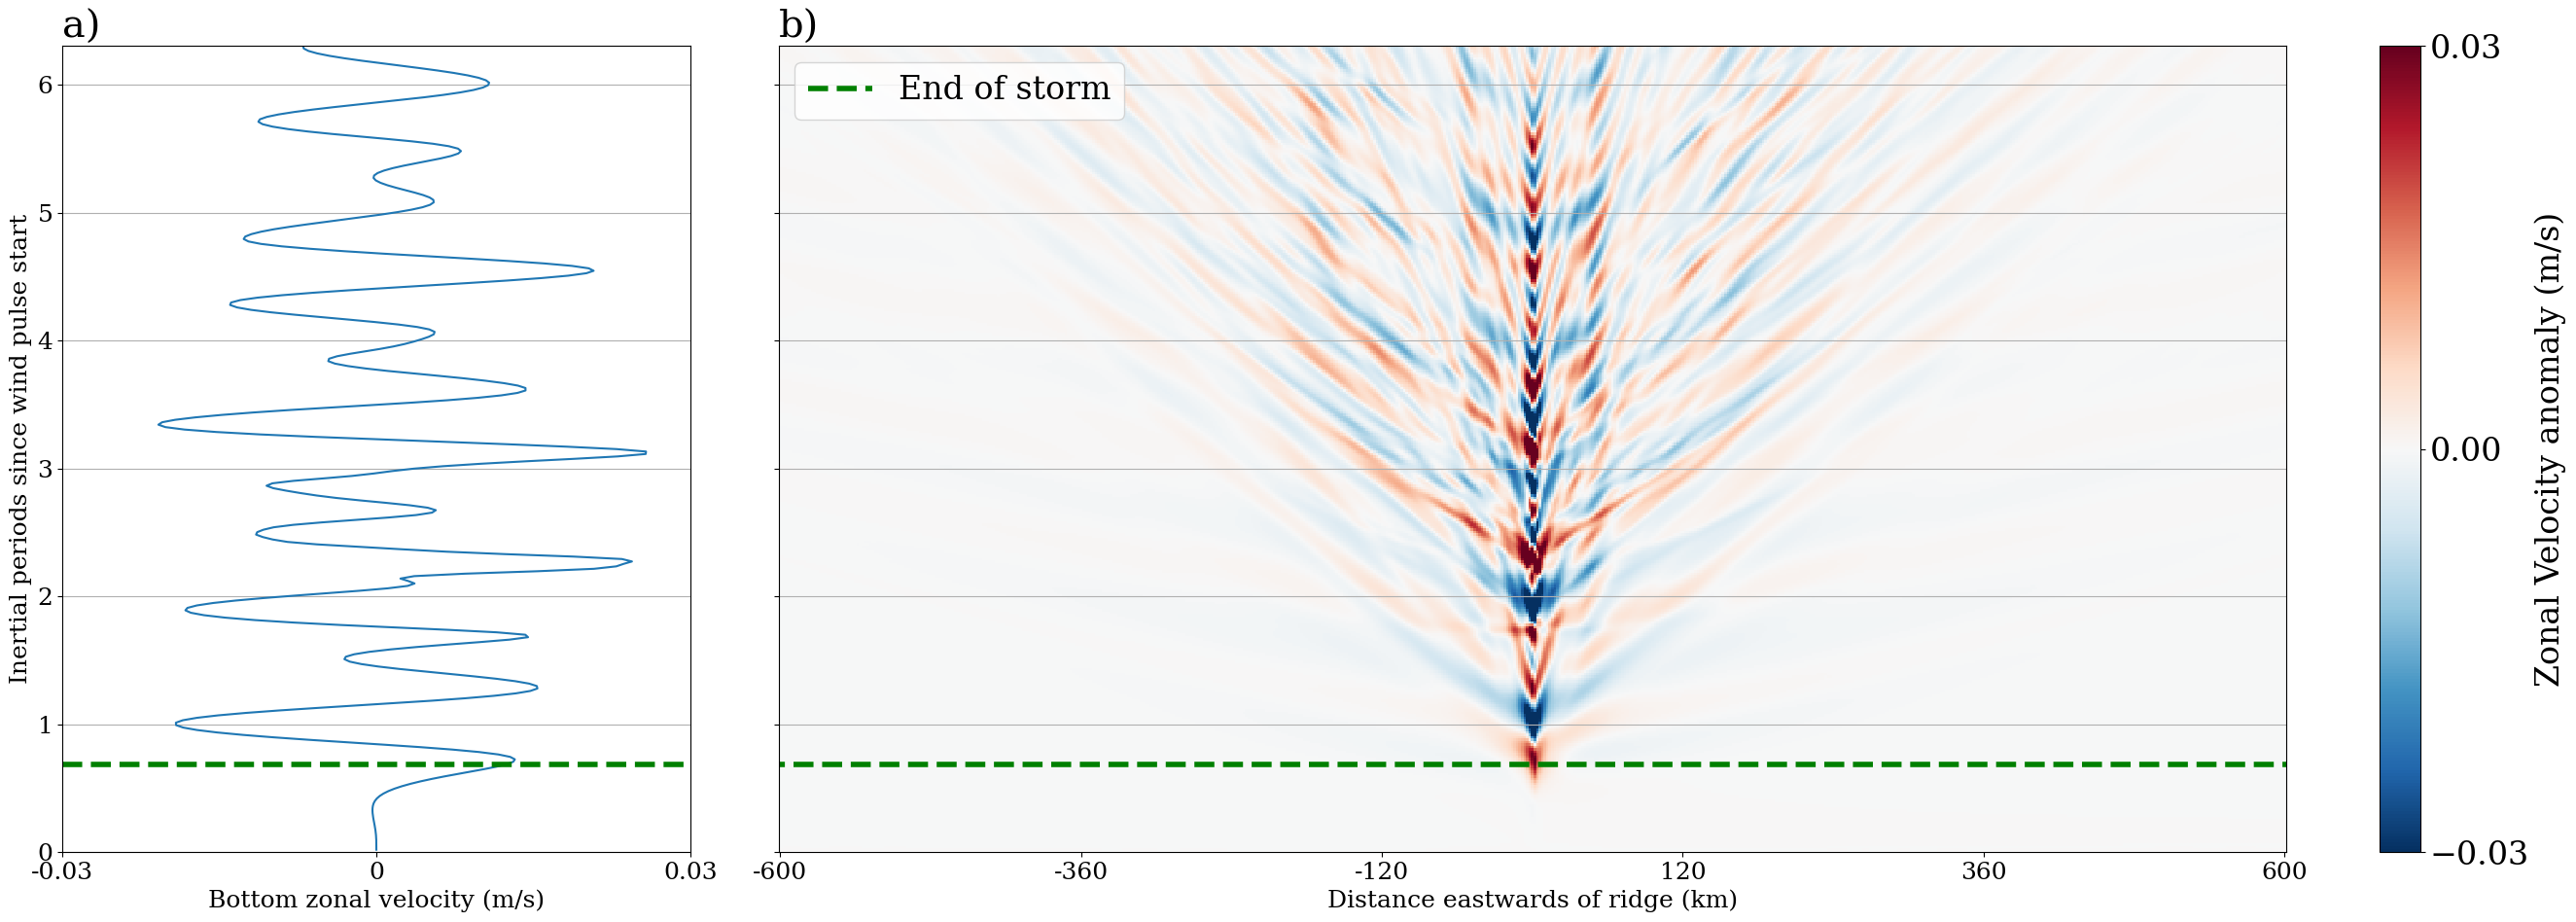

In [4]:
import matplotlib.gridspec as gridspec
import seaborn as sns
fig = plt.figure(figsize = (28,10))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3])

# Create the subplots
ax = [fig.add_subplot(gs[0, 0]),fig.add_subplot(gs[0, 1])]



cmap0 = matplotlib.cm.RdBu_r
cmap1 = sns.color_palette("rocket_r", as_cmap=True)
cmap1 = sns.cubehelix_palette(start=.75, rot=-1, as_cmap=True,light = 1)
cmap1 = "RdBu_r"
fp = (2 * np.pi / 0.0001) 
fp_hours = fp * 3600
# plot without colorbar 

yh = 150

uslice = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/default/archive/output*/u.nc",decode_times = False,decode_cf = False).u.sel(yh = yh,method = "nearest").isel(zl = 15).load()
ubottom = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/default/archive/output*/u.nc",decode_times = False,decode_cf = False).u.sel(yh = yh,method = "nearest").isel(zl = -1).isel(xq = 0).load()


uslice_anom = (uslice - uslice.isel(xq = 0)).assign_coords({"xq":uslice.xq.values * 1000}).rename({"xq":"xh"}).sel(xh = slice(-600000,600000))



vmin_s = -20
vmax_s = 17
vmin_s = -10
vmax_s = None
font = {'family' : 'serif',
        'weight':'normal',
        'size'   : 24}
matplotlib.rc('font', **font)
cmap = "coolwarm"
framedim = "time"
lw = 4

freq_xhlim = 1e-4
freq_timelim = 3e-4
xmin = -1000000
xmax = 1000000
freq_xhlim = None
freq_timelim = None
xmin = None
xmax = None



vmax = 0.03

uslice_anom.sel(xh = slice(xmin,xmax)).plot(ax = ax[1],vmin = -vmax,vmax = vmax,cmap = "RdBu_r",add_colorbar = False)
times = np.array([0,24,48,72,96])
times = np.linspace(0,6,7)
lons = np.linspace(-600000,600000,6)

ax[1].set_xlabel("Distance eastwards of ridge (km)")
ax[1].set_ylabel("")
ax[1].set_title("")
ax[1].set_yticks(times * fp)
ax[1].set_yticklabels([])
ax[1].set_ylim((0,396000))
ax[1].grid(axis = "y")
ax[1].set_xticks(lons)
ax[1].set_xticklabels((lons / 1000).astype(int))
ax[1].hlines(12 * 3600,-1000000,1000000,color = "green",lw = lw,linestyle = "--",label = "End of storm")
## Colorbar 0
# set location of legend to lower left
ax[1].set_title("b)",loc = "left") 
ax[1].legend(loc = "upper left")

ubottom.plot(ax = ax[0],y = "time")
ax[0].set_title("")
# ax[0].sharey(ax[1])
ax[0].grid(axis = "y")
ax[0].set_ylabel("Inertial periods since wind pulse start")
ax[0].set_yticks(times * fp)
ax[0].set_yticklabels((times).astype(int))
ax[0].set_ylim((0,396000))
ax[0].set_title("a)",loc = "left")
ax[0].set_xlim((-vmax,vmax))
ax[0].set_xticks([-vmax,0,vmax])
ax[0].set_xticklabels([-vmax,0,vmax])
ax[0].set_xlabel("Bottom zonal velocity (m/s)")
ax[0].hlines(12 * 3600,-vmax,vmax,color = "green",lw = lw,linestyle = "--",label = "Wind stops")

norm0 = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
## SEt the colorbar ticks
ticks = [-vmax,0,vmax]

# norm1 = matplotlib.colors.Normalize(vmin=vmin_s, vmax=vmax_s)

cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm0, cmap=cmap0),ax = ax[1],label = f"Zonal Velocity anomaly (m/s)",orientation = "vertical")
cbar.set_ticks(ticks)
plt.tight_layout()


$ \huge \omega = \frac{H}{n\pi}\sqrt{\left(f\frac{n\pi}{H}\right)^2 + k^2 N^2} $

$ \huge \partial \omega_k = \frac{Hk N^2}{n\pi\sqrt{\left(f\frac{n\pi}{H}\right)^2 + k^2 N^2}} $

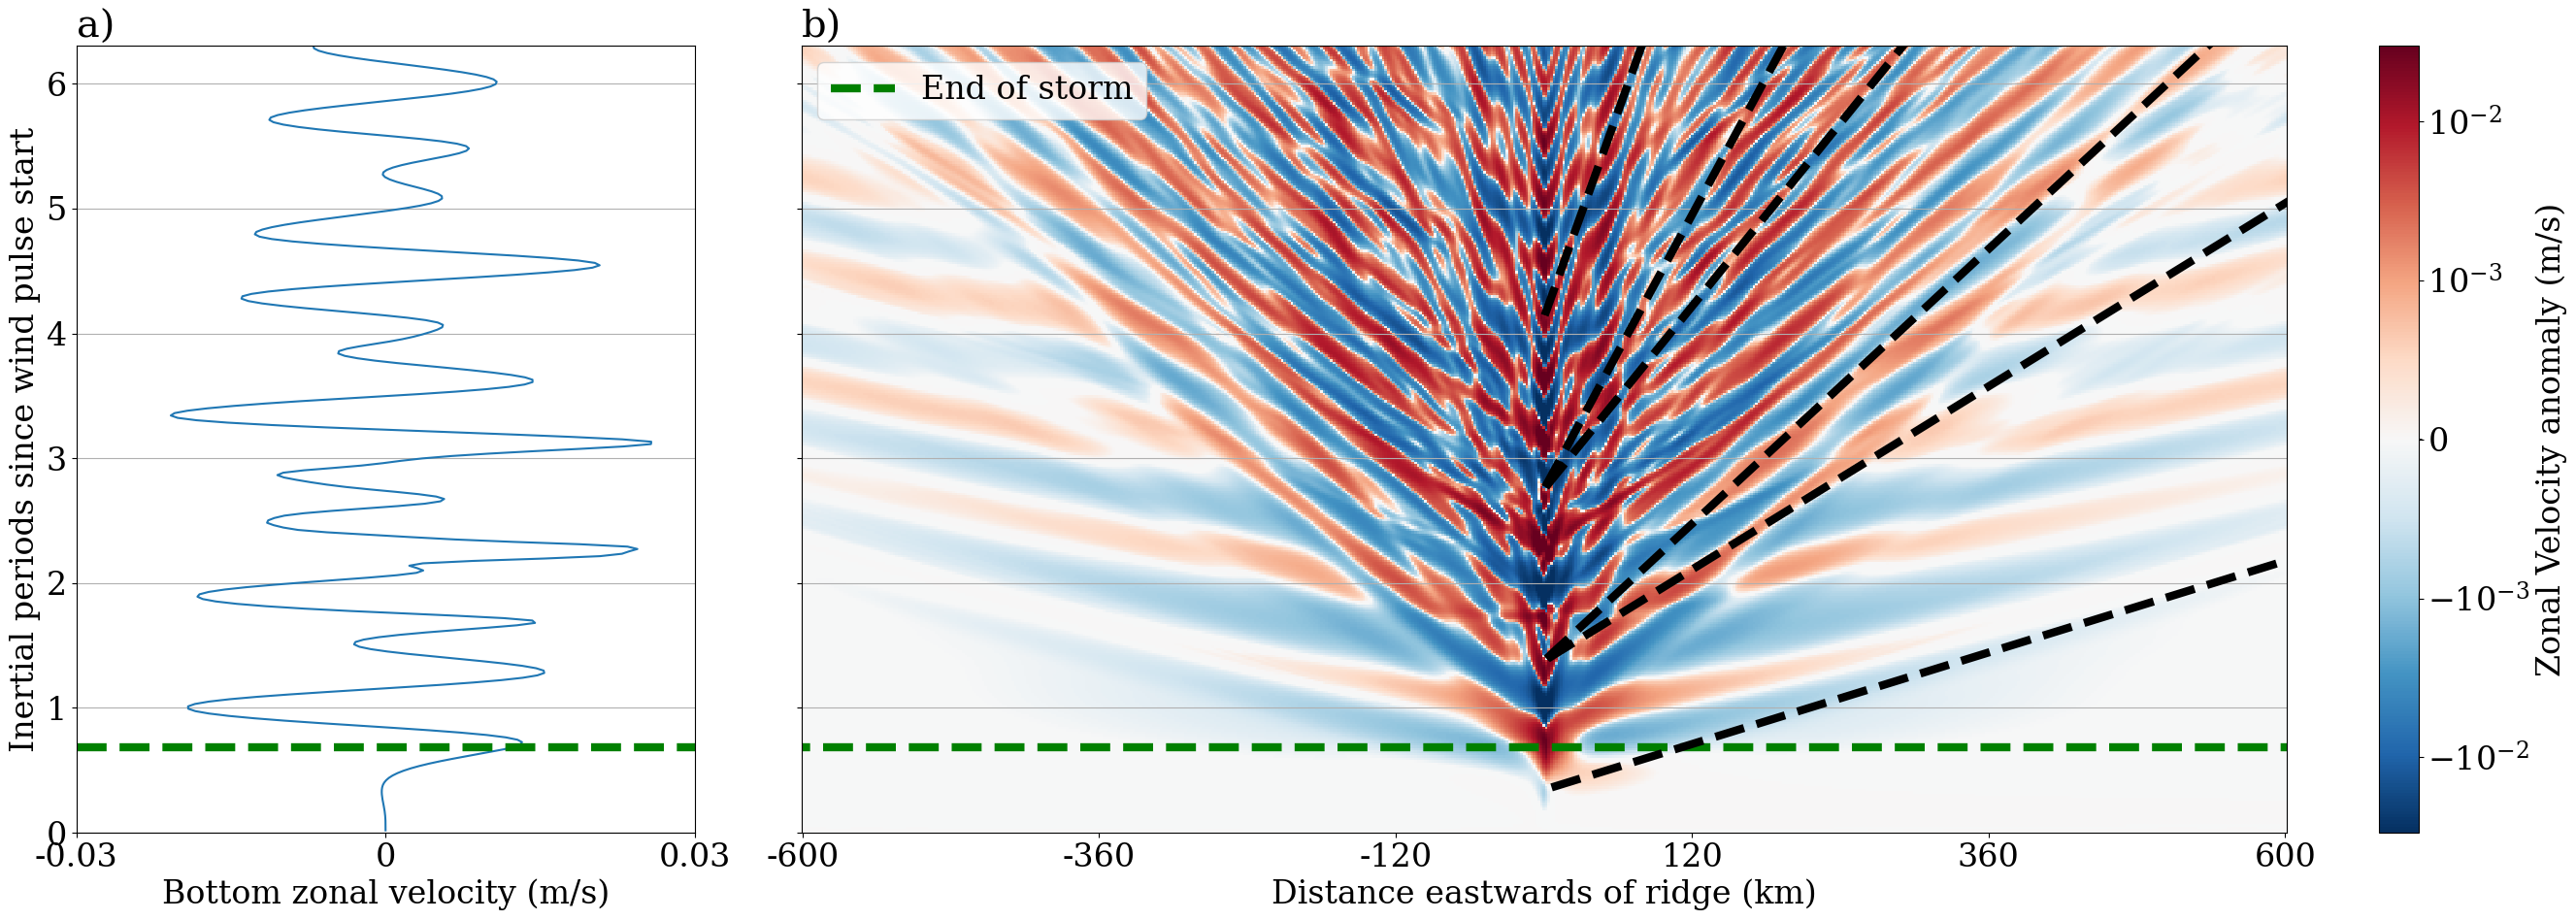

In [95]:
def GroupSpeed(k,n,harmonic = 1):
    # k /= 1000 # convert to m^-1
    H = 4000
    f = 0.0001 / (np.pi * 2) # f in s^-1
    N = np.sqrt((9.8 * 0.35) / (200 * 1025)) 
    # N = np.sqrt((2 * 9.8) / (4000 * 1027))  # N in s^-1
    m = np.pi * n / H
    K2 = k**2
    num = f**2 * m**2 + K2 * N ** 2
    den = m ** 2
    return (H * k * N**2 / (n * np.pi * np.sqrt(num))) # returns speed in m/s

GroupSpeed(1/20000,1)

import matplotlib.gridspec as gridspec
import seaborn as sns
fig = plt.figure(figsize = (28,10))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3])
import matplotlib.colors as colors
# Create the subplots
ax = [fig.add_subplot(gs[0, 0]),fig.add_subplot(gs[0, 1])]



cmap0 = matplotlib.cm.RdBu_r
# cmap2 = sns.color_palette("haline", as_cmap=True)
cmap1 = sns.cubehelix_palette(start=.75, rot=-1, as_cmap=True,light = 1)
cmap1 = "RdBu_r"
fp = (2 * np.pi / 0.0001) 
fp_hours = fp * 3600
# plot without colorbar 

yh = 150

# uslice = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/default/archive/output*/u.nc",decode_times = False,decode_cf = False).u.sel(yh = yh,method = "nearest").isel(zl = 15).load()
# ubottom = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/default/archive/output*/u.nc",decode_times = False,decode_cf = False).u.sel(yh = yh,method = "nearest").isel(zl = -1).isel(xq = 0).load()


uslice_anom = (uslice - uslice.isel(xq = 0)).assign_coords({"xq":uslice.xq.values * 1000}).rename({"xq":"xh"}).sel(xh = slice(-600000,600000))



vmin_s = -20
vmax_s = 17
vmin_s = -10
vmax_s = None
font = {'family' : 'serif',
        'weight':'normal',
        'size'   : 24}
matplotlib.rc('font', **font)
cmap = "coolwarm"
framedim = "time"
lw = 6

freq_xhlim = 1e-4
freq_timelim = 3e-4
xmin = -1000000
xmax = 1000000
freq_xhlim = None
freq_timelim = None
xmin = None
xmax = None

k = 1


norm = colors.SymLogNorm(linthresh=0.0001, linscale=0.002,vmin = -vmax,vmax = vmax,)

vmax = 0.03

uslice_anom.sel(xh = slice(xmin,xmax)).plot(
    ax = ax[1],cmap = "RdBu_r",add_colorbar = False,norm=norm)
# uslice_anom.sel(xh = slice(160000,xmax),time = slice(12*3600,None)).plot(ax = ax[1],vmin = -vmax * 0.1,vmax = vmax * 0.1,cmap = cmap1,add_colorbar = False)
times = np.array([0,24,48,72,96])
times = np.linspace(0,6,7)
lons = np.linspace(-600000,600000,6)

ax[1].set_xlabel("Distance eastwards of ridge (km)")
ax[1].set_ylabel("")
ax[1].set_title("")
ax[1].set_yticks(times * fp)
ax[1].set_yticklabels([])
ax[1].set_ylim((0,396000))
ax[1].grid(axis = "y")
ax[1].set_xticks(lons)
ax[1].set_xticklabels((lons / 1000).astype(int))
ax[1].hlines(12 * 3600,-1000000,1000000,color = "green",lw = lw,linestyle = "--",label = "End of storm")
## Colorbar 0


ax[1].plot(
    GroupSpeed(k,1) * uslice_anom.time.values,
    6 * 3600 + uslice_anom.time.values,color = "black",linestyle = "--",lw = lw)
ax[1].plot(
    GroupSpeed(k,2) * uslice_anom.time.values,
    24 * 3600 + uslice_anom.time.values,color = "black",linestyle = "--",lw = lw)
ax[1].plot(
    GroupSpeed(k,3) * uslice_anom.time.values,
    24 * 3600 + uslice_anom.time.values,color = "black",linestyle = "--",lw = lw)
ax[1].plot(
    GroupSpeed(k,4) * uslice_anom.time.values,
    48 * 3600 + uslice_anom.time.values,color = "black",linestyle = "--",lw = lw)
ax[1].plot(
    GroupSpeed(k,6) * uslice_anom.time.values,
    48 * 3600 + uslice_anom.time.values,color = "black",linestyle = "--",lw = lw)
ax[1].plot(
    GroupSpeed(k,9) * uslice_anom.time.values,
    72 * 3600 + uslice_anom.time.values,color = "black",linestyle = "--",lw = lw)
# set location of legend to lower left
ax[1].set_title("b)",loc = "left") 
ax[1].legend(loc = "upper left")


ubottom.plot(ax = ax[0],y = "time")
ax[0].set_title("")
# ax[0].sharey(ax[1])
ax[0].grid(axis = "y")
ax[0].set_ylabel("Inertial periods since wind pulse start")
ax[0].set_yticks(times * fp)
ax[0].set_yticklabels((times).astype(int))
ax[0].set_ylim((0,396000))
ax[0].set_title("a)",loc = "left")
ax[0].set_xlim((-vmax,vmax))
ax[0].set_xticks([-vmax,0,vmax])
ax[0].set_xticklabels([-vmax,0,vmax])
ax[0].set_xlabel("Bottom zonal velocity (m/s)")
ax[0].hlines(12 * 3600,-vmax,vmax,color = "green",lw = lw,linestyle = "--",label = "Wind stops")

norm0 = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
## SEt the colorbar ticks
ticks = [-1e-3,-1e-2,0,1e-2,1e-3]

# norm1 = matplotlib.colors.Normalize(vmin=vmin_s, vmax=vmax_s)

cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap0),ax = ax[1],label = f"Zonal Velocity anomaly (m/s)",orientation = "vertical")
cbar.set_ticks(ticks)
plt.tight_layout()


In [106]:
GroupSpeed(1/50000,1)

5.148360110581478

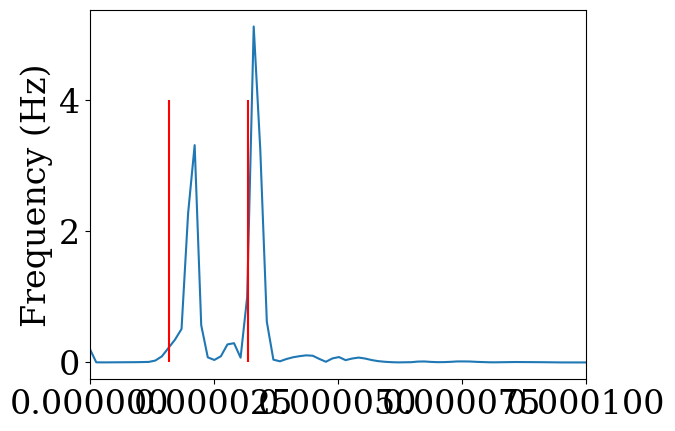

In [67]:
f = 0.0001 / (np.pi * 2) # f in s^-1
np.abs(xrft.power_spectrum(ubottom)).plot()
plt.title("")
plt.xlabel("")
plt.xlim(0,0.0001)
plt.ylabel("Frequency (Hz)")
plt.xlim(0,None)
plt.vlines(f,0,4,color = "red")
plt.vlines(2 * f,0,4,color = "red")

## Old plots below....

Text(0.0, 1.0, 'c)')

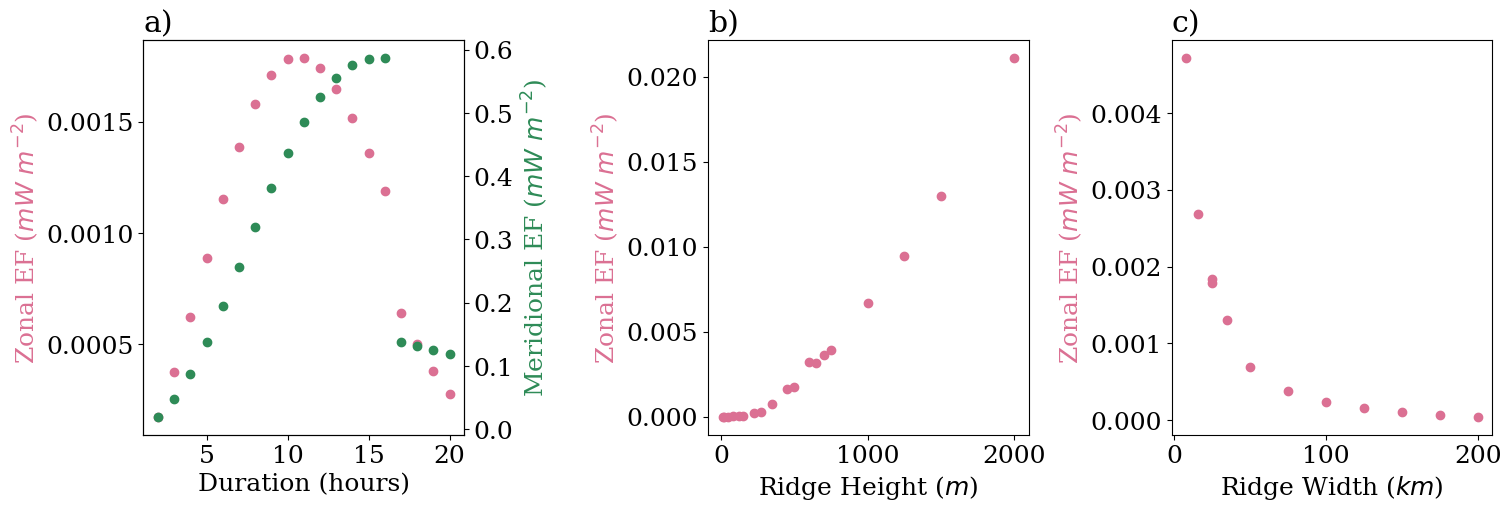

In [4]:
import pickle as pkl 

expts = ["duration","height","width"]
data = {}
for expt in expts:

    data[expt] = pkl.load(open(f"/home/149/ab8992/topographic-NIWs/outputdir/processed/lastone_{expt}.pkl","rb"))
    # pkl.dump(data,open(f"/home/149/ab8992/topographic-NIWs/outputdir/processed/new_{expt}.pkl","wb"))


data["height"][500] = data["duration"]["5.0"]
data["width"][25] = data["duration"]["5.0"]
del data["width"]["4"]


fig = plt.figure(figsize=(15, 5),constrained_layout=True)
gs = fig.add_gridspec(1, 4,width_ratios=[1,0.1,1, 1])

ax = [
        fig.add_subplot(gs[0]),
        fig.add_subplot(gs[2]),
        fig.add_subplot(gs[3])
]

color1= "palevioletred"
color2= "seagreen"

for i,expt in enumerate(expts):
    xax = np.array([float(i) for i in data[expt]])
    yax = np.array([data[expt][j].ZonalEF.values for j in data[expt]])
    yax2 = np.array([data[expt][j].MeridEF.values for j in data[expt]])

    # Now scale by the forcing width or ridge width
    if expt == "forcing_width":
        xax = xax[4:]
        yax = yax[4:]
        yax2 = yax2[4:]
        yax2 /= (xax * 1000)
        # yax2 /= (100000)
        xlabel = "Forcing Width (km)"
    else:
        yax2 /= 100000 # Divide by default forcing width
    if expt == "width":
        yax /= (xax * 1000)
        xlabel = r"Ridge Width ($km$)"
    else:
        yax /= 25000

    if expt == "height":
        xlabel = r"Ridge Height ($m$)"
    if expt == "duration":
        xax *= 2
        xlabel = r"Duration (hours)"

    yax *= 2000
    yax2 *= 2000 # Convert to mW, include the factor of 2 for the two sides of the ridge
    

    ax[i].scatter(xax,yax,color = color1)
    if expt not in ["height","width"]:
        ax2 = ax[i].twinx()
        ax2.set_ylabel(r"Meridional EF ($mW~ m^{-2}$)",color = color2)
        ax2.scatter(xax,yax2,color = color2)

    ax[i].set_ylabel(r"Zonal EF ($mW ~m^{-2}$)",color = color1)
    ax[i].set_xlabel(expt)
    ax[i].set_xlabel(xlabel)

ax[0].set_title("a)",loc = "left")
ax[1].set_title("b)",loc = "left")
ax[2].set_title("c)",loc = "left")


In [37]:
print(data["duration"]["5.0"].ZonalEF.values)


2.2004405952461576


In [38]:
print(1000 * data["duration"]["5.0"].ZonalEF.values / 25000)
print(1000 * data["duration"]["5.0"].MeridEF.values / 100000)

0.0880176238098463
21.362047295689564


In [45]:
100 * 0.08 / 21

0.38095238095238093

In [47]:
1 / 21

0.047619047619047616

In [42]:
print(1000 * data["height"]["2000"].ZonalEF.values / 25000)
print(1000 * data["height"]["2000"].MeridEF.values / 100000)


1.0443689591366276
27.836223325709422


In [14]:
del data

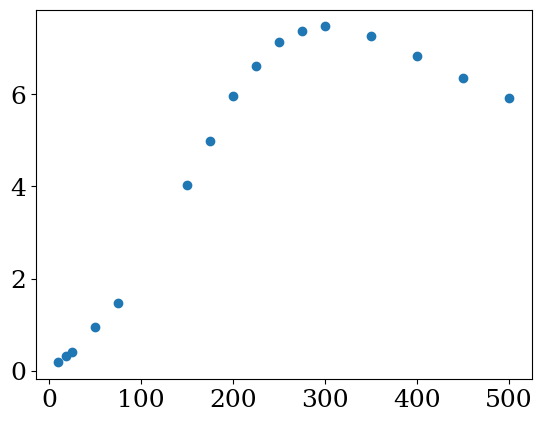

In [15]:
expt = "forcing_width"
xax = np.array([float(i) for i in data[expt]])
yax = np.array([data[expt][j].ZonalEF.values for j in data[expt]])
scaling = 100 / xax
plt.scatter(xax,yax * scaling)
# data["forcing_width"]["500"].ZonalEF.values / 

In [169]:
merid = xr.open_mfdataset(f"/home/149/ab8992/topographic-NIWs/outputdir/common_mixedlayer/merid/*.nc",decode_times = False,decode_cf = False).isel(xh = 0,xq = 0).sel(yq = 1950).load()

In [181]:
p = al.calculate_pressure(merid.e,merid.v.zl).isel(yh = 800).isel(zl = 5)

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.01/lib/python3.10/site-packages/xarray/core/computation.py:825: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


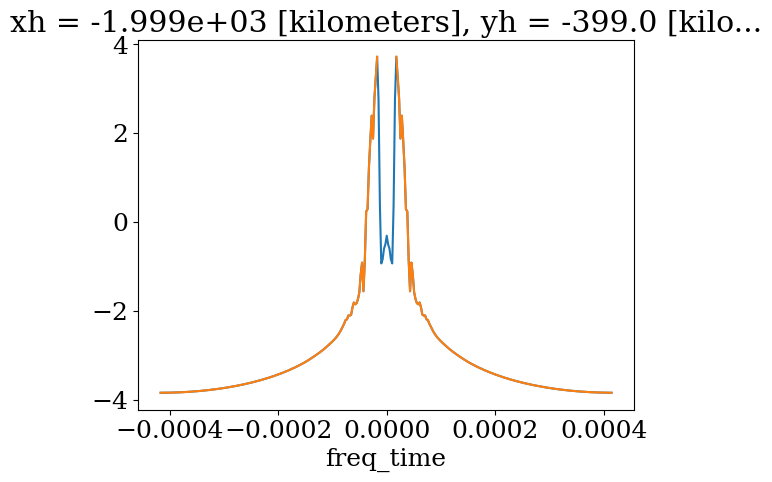

In [201]:
def sup_filter(field):
    f = 0.0001 / (np.pi * 2)
    FIELD = xrft.fft(field.load(),dim = "time")
    FIELD_filtered = FIELD.where(np.abs(FIELD.freq_time) > f+f*0.1,0)
    return np.real(xrft.ifft(FIELD_filtered,dim = "freq_time"))

a = merid.u.isel(yh = 800).isel(zl = 5)
f = 0.0001 / (np.pi * 2)


FIELD = xrft.fft(a,dim = "time")
FIELD_filtered = FIELD.where(np.abs(FIELD.freq_time) > f+f*0.1,0)
np.log(np.abs(FIELD)).plot()
np.log(np.abs(FIELD_filtered)).plot()

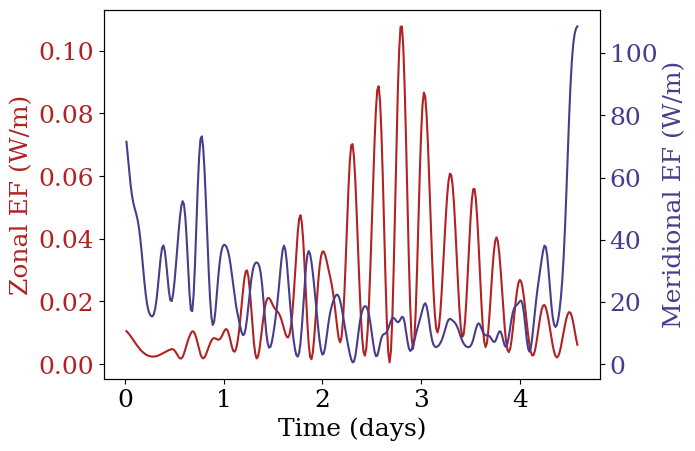

In [203]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
color1 = "firebrick"
color2 = "darkslateblue"
# Plot ZonalEF on the primary y-axis
## Multiply by 4000 for depth, then the rest is for scaling
(4000 * ef.ZonalEF.sel(xh = 200,method = "nearest")).plot(ax = ax1,color = color1)
ax1.set_ylabel('Zonal EF (W/m)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
(4000 * ef.MeridEF.sel(yh = 200,method = "nearest")).plot(ax = ax2,color = color2)
ax2.set_ylabel('Meridional EF (W/m)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax1.set_xlabel("Time (days)")
ax1.set_xticks([3600 * 24 * i for i in range(0,5)])
ax1.set_xticklabels([i for i in range(0,5)])
ax1.set_title("")
ax2.set_title("")

# Set y-ticks for both axes based on the magnitudes of the values
# ax1.set_yticks(range(int(1000 * ef.ZonalEF.min()), int(1000 * ef.ZonalEF.max()) + 1, 1000))
# ax2.set_yticks(range(int(1000 * ef.MeridEF.min()), int(1000 * ef.MeridEF.max()) + 1, 1000))

plt.show()


In [204]:
distance = 200 
zef = (4000 * ef.ZonalEF).sel(xh = distance,method = "nearest").mean("time").values
mef = (4000 * ef.MeridEF).sel(yh = distance,method = "nearest").mean("time").values
print(zef,mef,100 * zef / mef)

0.022252002242441435 21.850648643802213 0.10183680404724764


In [133]:
# distance = 
print((4000 * ef.ZonalEF).sel(xh = 200,method = "nearest").max("time").values)
print((4000 * ef.MeridEF).sel(yh = 200,method = "nearest").max("time").values)

0.11635980446907171
241.69249534190413


# Perturbation expt plots

## Older plots below

In [2]:
data = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/outputdir/common_mixedlayer/zonal/*.nc",decode_times = False,decode_cf = False)


zon_anom = (data - data.mean("xh")).isel(zi = -2).sel(xh = slice(-200,200))
merid = data.isel(zi = 1).sel(xh = slice(-200,200)) + 800
topog = data.isel(zi = -1).sel(xh = slice(-200,200))

merid = (merid * 0) + merid.mean("xh")

# topog.plot()
# plt.figure()
# zon_anom.plot()
# plt.figure()
# merid.plot()
def normalise(x):
    return (x - x.min()) / (x.max() - x.min())

def interp(z,xfac = 10,yfac = 10):

    xnew = np.linspace(z.xh[0],z.xh[-1],round(z.xh.shape[0]*xfac))
    ynew = np.linspace(z.yh[0],z.yh[-1],round(z.yh.shape[0]*yfac))
    znew = z.interp(xh = xnew,yh = ynew)
    return znew

Z_zonal = normalise(zon_anom) * 2
Z_merid = -1 * normalise(merid) + 4.5
Z_topog = normalise(topog) - 2

# # Interpolate Z variables onto higher resolution grids using scipy
#Flip merid for aesthetic purposes

Z_topog = interp(Z_topog,xfac = 10,yfac = 0.05).persist()
# Z_zonal = interp(Z_zonal,xfac = 5,yfac = 5).persist()
# Z_merid = interp(Z_merid,xfac = 0.01,yfac = 10).persist()

# Lower Res for fast plotting
# Z_topog = interp(Z_topog,xfac = 0.5,yfac = 0.05).persist()
Z_zonal = interp(Z_zonal,xfac = 0.5,yfac = 0.5).persist()
Z_merid = interp(Z_merid,xfac = 0.1,yfac = 0.5).persist()


## Make Hovmöller and spectral plot

In [5]:
path = "duration_ridge_20layer/duration_ridge_20layer_duration-1"

def horizontal_eslice(path,dim = "xh",var = "e",vcoord = "zi"):
    eslice = xr.open_mfdataset(
        f"/home/149/ab8992/bottom_near_inertial_waves/revision/{path}/archive/output00*/{var}_10min.nc",chunks = {dim:500,"time":500},decode_times = False,parallel=True).isel({"yh" : 250,"time" : slice(0,4152//2),"zi" : 13})


    eslice = eslice[var].assign_coords({"time":("time",eslice.time.values * 60),
                            dim:(dim,eslice[dim].values * 1000)
        })

    eanom = (eslice - eslice.mean(dim)).load()
    eslice.close()
    eanom_flipped = xr.DataArray(
        data = eanom[::-1,:],
        coords = [600 - eanom.time[::-1],eanom[dim]],
        dims = ["time",dim]
    )

    extended = xr.concat([eanom_flipped,eanom],dim = "time")

    ###  COMBINE INTO ONE FUNCTIon
    strat = 1
    if "strat" in path:
        strat = float(path.split("-")[-1])

    print("loading")
    e = extended.load()
    print("done")
    spectrum = xrft.power_spectrum(e,dim=["time",dim],true_phase = True,true_amplitude = True)

    ## Commentted out include spectrum in saved files
    out = xr.Dataset(
        {"spectrum":spectrum.sel({"freq_time" : slice(0,None),f"freq_{dim}" : slice(0,None)}),"slice":eslice}
    )

    return out

data = horizontal_eslice(path,dim = "xh",var = "e",vcoord = "zi")

data["slice"].to_netcdf(f"/g/data/v45/ab8992/bottom_iwbs/20layerhovmoller_for_figure.nc")
data["spectrum"].to_netcdf(f"/g/data/v45/ab8992/bottom_iwbs/20layerspectrum_for_figure.nc")

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.01/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


loading
done


In [19]:
# spectrum = xr.open_dataarray("/g/data/v45/ab8992/bottom_iwbs/20layerspectrum_for_figure.nc").persist()
# eslice = xr.open_dataarray("/g/data/v45/ab8992/bottom_iwbs/20layerhovmoller_for_figure.nc").persist()

def omega(k,f,N,n,H,l = 0):
    f = np.full(k.shape,f)
    N = np.full(k.shape,N)
    n = np.full(k.shape,n)
    H = np.full(k.shape,H)
    l = np.full(k.shape,l)
    K2 = k**2 + l**2
    
    m = np.pi * n / H
    num = f**2 * m**2 + K2 * N ** 2
    den = K2 + m ** 2
    return np.sqrt(num / den)


def vmodes(k,n):
    k = k
    f = 0.0001 / (np.pi * 2)
    N = np.sqrt((2 * 9.8) / (3275 * 1027))  # N in s^-1
    # N = np.sqrt((2 * 9.8) / (4000 * 1027))  # N in s^-1
    print(f / N)
    m = np.pi * n / 4000
    K2 = 2 * k**2
    num = f**2 * m**2 + K2 * N ** 2
    den = m ** 2
    return np.sqrt(num / den)



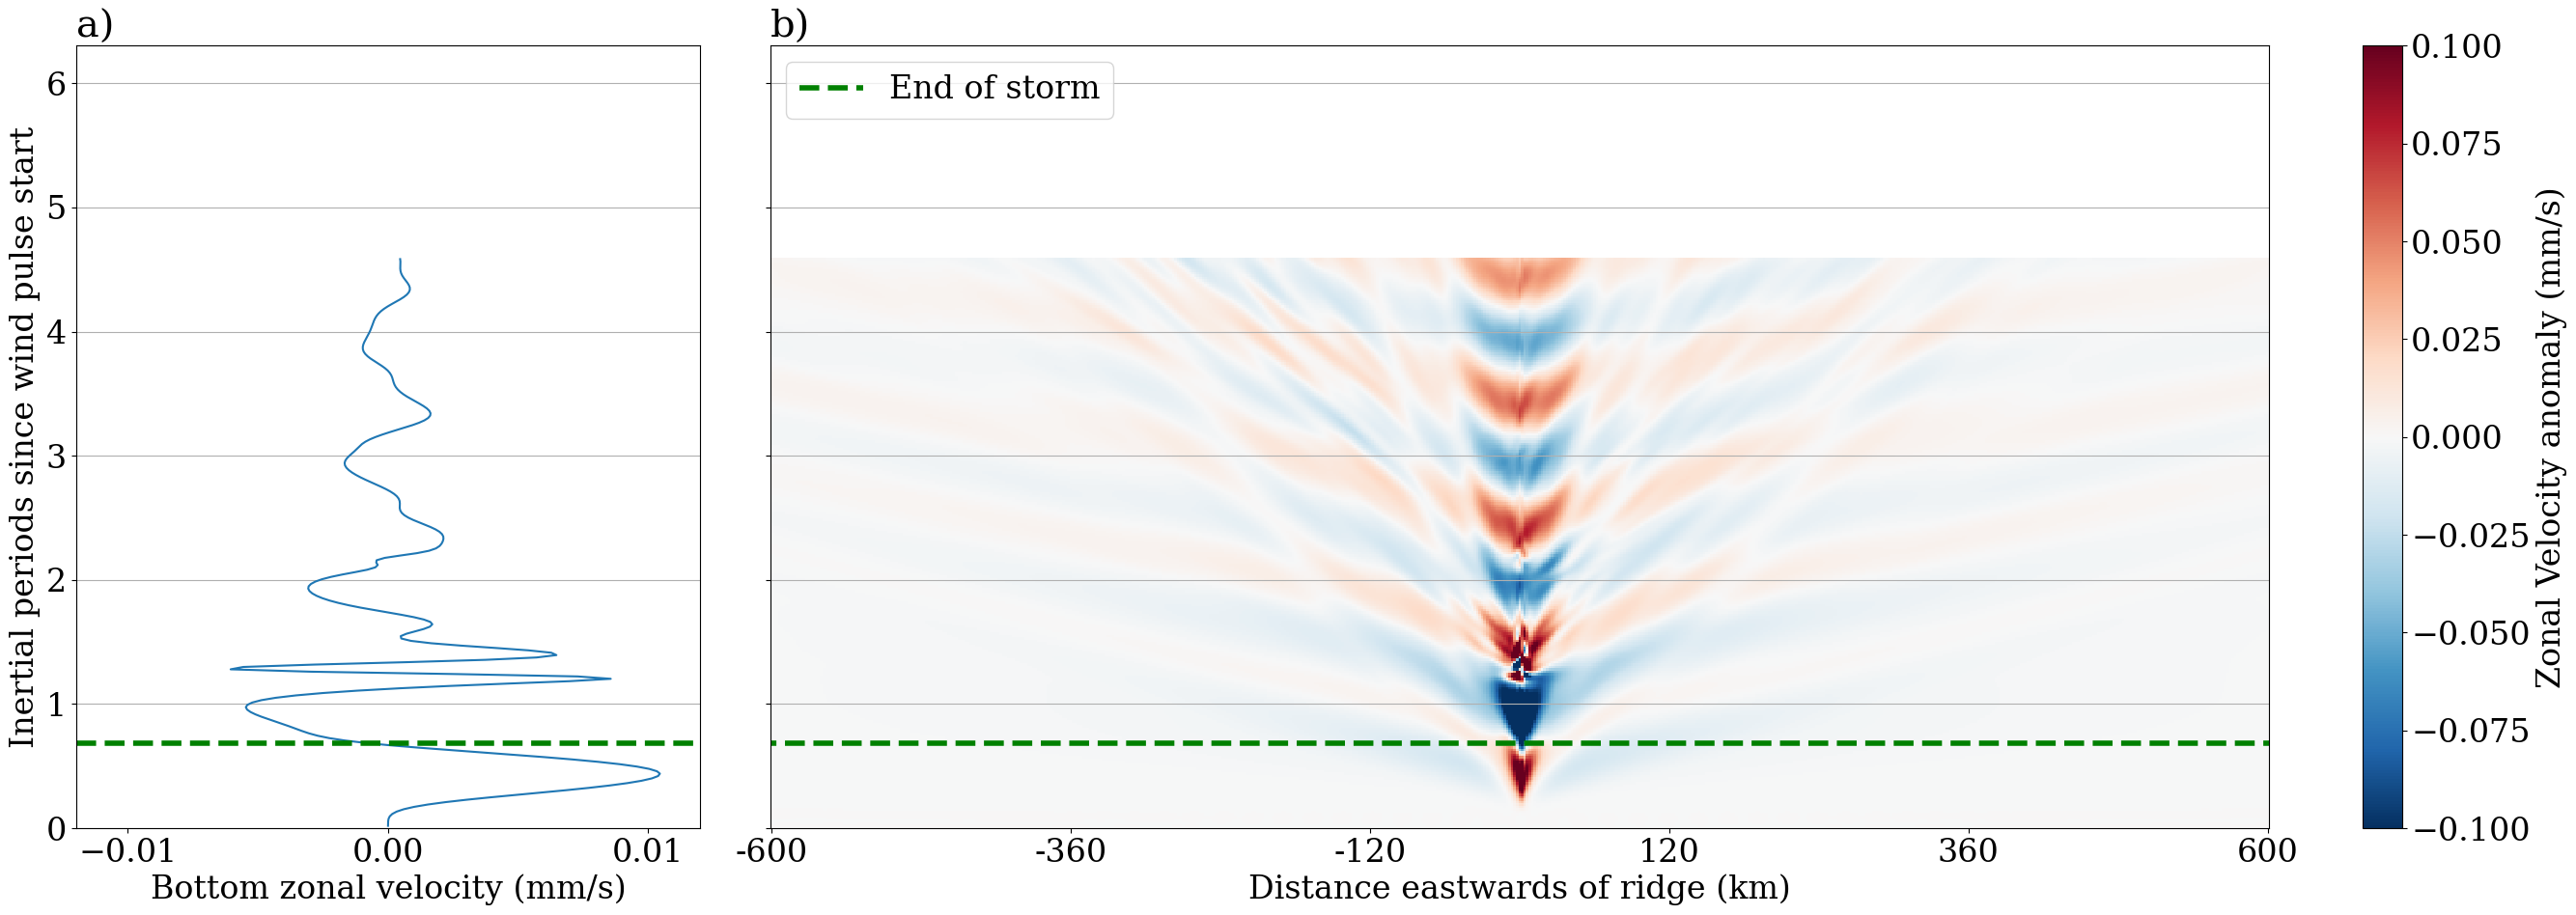

In [15]:
import matplotlib.gridspec as gridspec
import seaborn as sns
fig = plt.figure(figsize = (28,10))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3])

# Create the subplots
ax = [fig.add_subplot(gs[0, 0]),fig.add_subplot(gs[0, 1])]



cmap0 = matplotlib.cm.RdBu_r
cmap1 = sns.color_palette("rocket_r", as_cmap=True)
cmap1 = sns.cubehelix_palette(start=.75, rot=-1, as_cmap=True,light = 1)
cmap1 = "RdBu_r"
fp = (2 * np.pi / 0.0001) 
fp_hours = fp * 3600
# plot without colorbar 

# uslice = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/common_common/archive/output*/u.nc",decode_times = False,decode_cf = False).u.sel(yh = slice(-5,5)).isel(zl = 15).mean("yh").load()
# ubottom = xr.open_mfdataset("/home/149/ab8992/topographic-NIWs/rundirs/common/common_common/archive/output*/u.nc",decode_times = False,decode_cf = False).u.sel(yh = slice(-5,5)).isel(zl = -1).mean("yh").isel(xq = 0).load()


uslice_anom = (uslice - uslice.isel(xq = 0)).assign_coords({"xq":uslice.xq.values * 1000}).rename({"xq":"xh"}).sel(xh = slice(-600000,600000))

spectrum = xrft.power_spectrum(uslice_anom,dim=["xh","time"],true_phase = True,true_amplitude = True)


vmin_s = -20
vmax_s = 17
vmin_s = -10
vmax_s = None
font = {'family' : 'serif',
        'weight':'normal',
        'size'   : 24}
matplotlib.rc('font', **font)
cmap = "coolwarm"
framedim = "time"
lw = 4

freq_xhlim = 1e-4
freq_timelim = 3e-4
xmin = -1000000
xmax = 1000000
freq_xhlim = None
freq_timelim = None
xmin = None
xmax = None
vmax = 0.01
uslice_anom.sel(xh = slice(xmin,xmax)).plot(ax = ax[1],vmin = -vmax,vmax = vmax,cmap = "RdBu_r",add_colorbar = False)
times = np.array([0,24,48,72,96])
times = np.linspace(0,6,7)
lons = np.linspace(-600000,600000,6)

ax[1].set_xlabel("Distance eastwards of ridge (km)")
ax[1].set_ylabel("")
ax[1].set_title("")
ax[1].set_yticks(times * fp)
ax[1].set_yticklabels([])
ax[1].set_ylim((0,396000))
ax[1].grid(axis = "y")
ax[1].set_xticks(lons)
ax[1].set_xticklabels((lons / 1000).astype(int))
ax[1].hlines(12 * 3600,-1000000,1000000,color = "green",lw = lw,linestyle = "--",label = "End of storm")
## Colorbar 0
# set location of legend to lower left
ax[1].set_title("b)",loc = "left") 
ax[1].legend(loc = "upper left")

ubottom.plot(ax = ax[0],y = "time")
ax[0].set_title("")
# ax[0].sharey(ax[1])
ax[0].grid(axis = "y")
ax[0].set_ylabel("Inertial periods since wind pulse start")
ax[0].set_yticks(times * fp)
ax[0].set_yticklabels((times).astype(int))
ax[0].set_ylim((0,396000))
ax[0].set_title("a)",loc = "left")
ax[0].set_xlim((-0.012,0.012))
ax[0].set_xticks([-0.01,0,0.01])
# ax[0].set_xticklabels([-1,0,1])
ax[0].set_xlabel("Bottom zonal velocity (mm/s)")
ax[0].hlines(12 * 3600,-0.012,0.012,color = "green",lw = lw,linestyle = "--",label = "Wind stops")

norm0 = matplotlib.colors.Normalize(vmin=-0.1, vmax=0.1)
norm1 = matplotlib.colors.Normalize(vmin=vmin_s, vmax=vmax_s)

plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm0, cmap=cmap0),ax = ax[1],label = f"Zonal Velocity anomaly (mm/s)",orientation = "vertical")
plt.tight_layout()


# Movie

In [3]:



def make_movie(data,plot_function,framerate = 20,parallel = False,plot_kwargs = {}):
    """
    Custom function to make a movie of a plot function. Saves to a folder in dropbox. Intermediate frames are saved to /tmp
    data_list : dictionary of dataarrays required by plot function
    plot_function : function to plot data
    runname : name of the run eg full-20
    plotname : name of the plot eg "h_energy_transfer"
    plot_kwargs : kwargs to pass to plot function
    """
    from pathlib import Path
    runname = "20layer"
    plotname = "movie"
    tmppath = Path(f"/g/data/v45/ab8992/movies_tmp/bottomiws")
    outpath = Path(f"/g/data/v45/ab8992/dropbox/bottomiw_movies/{runname}")
    print(tmppath)
    ## Log the start of movie making

    if os.path.exists(tmppath):
        shutil.rmtree(tmppath)
    os.makedirs(tmppath)
    if not os.path.exists(outpath):
        os.makedirs(outpath)
    


    ## Make each frame of the movie and save to tmpdir
    if parallel == True:
        # @dask.delayed
        # def process_chunk(_data,i):
        #     fig = plot_function(_data,**plot_kwargs)
        #     fig.savefig(tmppath / f"frame_{str(i).zfill(5)}.png")
        #     plt.close()
        #     return None
        
        # frames = [process_chunk(data.isel(time = i),i) for i in range(len(data.time))]
        # dask.compute(*frames)
        pass

    ## Do the same thing but in serial
    else:
        for i in range(len(data.time)):
            fig = plot_function(data.isel(time = i))
            fig.savefig(tmppath / f"frame_{str(i).zfill(5)}.png")
            plt.close()


    print(f"Finished making frames")
    print(f"ffmpeg -r {framerate}  -i {tmppath}/frame_%05d.png -s 1920x1080 -c:v libx264 -pix_fmt yuv420p {str(outpath) + plotname}.mp4")
    result = subprocess.run(
            f"ffmpeg -y -r {framerate} -i {tmppath}/frame_%05d.png -s 1920x1080 -c:v libx264 -pix_fmt yuv420p {str(outpath / plotname)}.mp4",
            shell = True,
            capture_output=True,
            text=True,
        )
    print(f"ffmpeg finished with returncode {result.returncode} \n\n and output \n\n{result.stdout}")
    print(
        f"ffmpeg finished with returncode {result.returncode}",
    )
    print(result.stderr)
    print(result.stdout)
    if str(result.returncode) == "1":
        print(f"ffmpeg output: {result.stdout}")
    return